In [1]:
'''Imports'''
#General python packages
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt

#For solving systems of equations
import sympy as sp
from sympy.solvers import solve

#Utils
from functions import *

In [2]:
'''Setup'''
#Dictionary of site info -- for thresholds and windows of good data
steps = 50
metadata = {'CA-SCB' : {'istart' : 443, 'iend' : 1416, 'thresholds' : np.linspace(-0.35, 0.1, steps)}, 
            'DE-Hte' : {'istart' : 0, 'iend' : 2922, 'thresholds' : np.linspace(-0.6, 0.4, steps)}, 
            'DE-SfN' : {'istart' : 185, 'iend' : 367, 'thresholds' : np.linspace(-0.20, -0.05, steps)}, 
            'DE-Zrk' : {'istart' : 1095, 'iend' : 2190, 'thresholds' : np.linspace(-0.05, 0.75, steps)}, 
            'FI-Si2' : {'istart' : 479, 'iend' : 1018, 'thresholds' : np.linspace(0.06, 0.17, steps)}, 
            'FR-LGt' : {'istart' : 0, 'iend' : 729, 'thresholds' : np.linspace(-0.45, -0.15, steps)}, 
            'JP-BBY' : {'istart' : 0, 'iend' : 1460, 'thresholds' : np.linspace(-0.20, 0.15, steps)}, 
            'NZ-Kop' : {'istart' : 0, 'iend' : 1460, 'thresholds' : np.linspace(-0.25, 0, steps)}, 
            'SE-Deg' : {'istart' : 0, 'iend' : 1825, 'thresholds' : np.linspace(-0.25, 0.3, steps)}}


In [7]:
'''Run crossing time analysis'''
sites = ["CA-SCB", "DE-Hte", "DE-SfN", "DE-Zrk", "FI-Si2", "FR-LGt", "JP-BBY", "NZ-Kop", "SE-Deg"]
sites_storage = pd.DataFrame({'Site' : np.arange(len(sites)*steps), 
                              'Threshold' : np.arange(len(sites)*steps), 
                              'N_crosses' : np.arange(len(sites)*steps), 
                              'T_avg' : np.arange(len(sites)*steps), 
                              'k1' : np.arange(len(sites)*steps), 
                              'k2' : np.arange(len(sites)*steps), 
                              'CH_avg' : np.arange(len(sites)*steps)})
counter = 0

for site in sites:
    for thresh in metadata[site]['thresholds']:
        daily = pd.read_csv('./data/cleaned/' + site + '_normalized.csv')

        #Step 0: Plot data
        #plt.plot(daily.WTD_F)
        #plt.title('Site: ' + str(site))
        #plt.show()

        #Step 1: Set a single threshold -- will be looped through in future iterations
        WTD_sample = daily.WTD_F[metadata[site]['istart']:metadata[site]['iend']].dropna().reset_index(drop = True)

        #Determine the number of crosses
        n = ncrosses(WTD_sample, thresh)

        #Determine the average time spent above or below before crossing
        t_vec, t = crossTime(WTD_sample, thresh)

        #Correlate this to a k1 and k2 value
        k1param, k2param, _ = switch_param(WTD_sample, thresh)

        #Step 2: Determine average emissions of site
        ch_sample = daily.FCH4_F_NORM[metadata[site]['istart']:metadata[site]['iend']].dropna().reset_index(drop = True)
        mean_ch = np.mean(ch_sample)

        #Step 3: Log data
        sites_storage['Site'][counter] = site
        sites_storage['Threshold'][counter] = thresh
        sites_storage['N_crosses'][counter] = n
        sites_storage['T_avg'][counter] = t
        sites_storage['k1'][counter] = k1param
        sites_storage['k2'][counter] = k2param
        sites_storage['CH_avg'][counter] = mean_ch
        counter = counter + 1

        #Step 4: Repeat for all sites


C:\Users\mwjones\AppData\Local\Temp\1\ipykernel_1236\1947726552.py:38: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sites_storage['Site'][counter] = site
C:\Users\mwjones\AppData\Local\Temp\1\ipykernel_1236\1947726552.py:38: FutureWarning: 

In [12]:
'''Moving Window Version'''
window_length = 30

site_wind = []
wind_no = []
thresh_wind = []
n_wind = []
t_wind = []
k1_wind = []
k2_wind = []
ch_wind = []

for site in sites:
    for thresh in metadata[site]['thresholds']:
        counter = 0
        daily = pd.read_csv('./data/cleaned/' + site + '_normalized.csv')

        #Step 0: Plot data
        #plt.plot(daily.WTD_F)
        #plt.title('Site: ' + str(site))
        #plt.show()

        for i in range(metadata[site]['istart'], metadata[site]['iend']-(window_length-1)):
            #Step 1: Set a single threshold -- will be looped through in future iterations
            #Run a window of specified length
            WTD_sample = daily.WTD_F[i:i+window_length].dropna().reset_index(drop = True)

            #Determine the number of crosses
            n = ncrosses(WTD_sample, thresh)

            #Determine the average time spent above or below before crossing
            t_vec, t = crossTime(WTD_sample, thresh)

            #Correlate this to a k1 and k2 value
            #k1param, k2param, _ = switch_param(WTD_sample, thresh)

            #Step 2: Determine average emissions of site
            ch_sample = daily.WTD_F[i:i+window_length].dropna().reset_index(drop = True)
            mean_ch = np.mean(ch_sample)

            #Step 3: Log data
            site_wind.append(site)
            wind_no.append(counter)
            thresh_wind.append(thresh)
            n_wind.append(n)
            t_wind.append(t)
            #k1_wind.append(k1param)
            #k2_wind.append(k2param)
            ch_wind.append(mean_ch)
            counter = counter + 1

        #Step 4: Repeat for all sites

#%%
#Append lists into DataFrame
sites_storage_window = pd.DataFrame({'Site' : site_wind, 
                              'Window' : wind_no,
                              'Threshold' : thresh_wind, 
                              'N_crosses' : n_wind, 
                              'T_avg' : t_wind, 
                              'CH_avg' : ch_wind})

c:\Users\mwjones\OneDrive - DOI\Desktop\1_Codes\dichotomous\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\mwjones\OneDrive - DOI\Desktop\1_Codes\dichotomous\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\mwjones\OneDrive - DOI\Desktop\1_Codes\dichotomous\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\mwjones\OneDrive - DOI\Desktop\1_Codes\dichotomous\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\mwjones\OneDrive - DOI\Desktop\1_Codes\dichotomous\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods.

KeyboardInterrupt: 

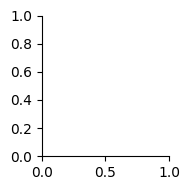

In [29]:
'''Plot'''
sns.displot(data = sites_storage_window, x = 'N_crosses', y = 'CH_avg', kind = 'kde',
                 #col = 'Site', col_wrap = 3, 
                 height = 2)
#ax.set_xlim(0, 180)
#ax.set_ylim(-20, 20)
plt.xlabel('Average Crossing Time')
plt.ylabel('Average Turbulent CH4 Flux [nmolCH4 m-2 s-1]')
# %%
